All Dependencies

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications import VGG19
from sklearn.model_selection import train_test_split
from glob import glob

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU available: []


Mount Drive (Execute only if using Colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset

  Converted 1ch → 3ch: (270, 64, 64, 3)
  Converted 1ch → 3ch: (30, 64, 64, 3)
  Converted 1ch → 3ch: (270, 128, 128, 3)
  Converted 1ch → 3ch: (30, 128, 128, 3)


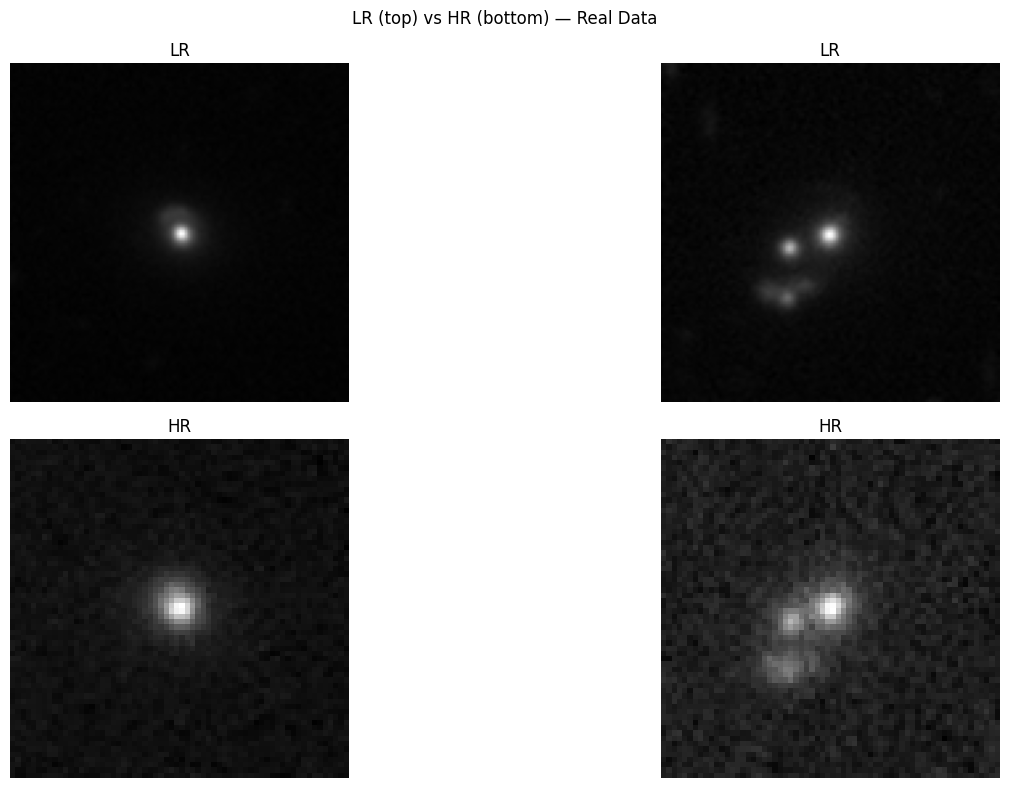

In [ ]:
file_path = "/content/drive/MyDrive/Tasks/SR_2/Dataset"

# Initialise parameters
LR_SIZE = 64
HR_SIZE = 128
SCALE = 2
BATCH_SIZE = 8
EPOCHS = 200
LEARNING_RATE = 5e-5
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
CLASS_NAMES = ["LR","HR"]

def load_dataset(dataset_dir):

  img_dict = defaultdict(list)
  LR = []
  HR = []

  for d in os.listdir(dataset_dir):
    if d == "LR":
      lr_dir = os.path.join(dataset_dir, d)
      for img in os.listdir(lr_dir):
        if img.endswith(".npy"):
          img_path = os.path.join(lr_dir, img)
          img_data = np.load(img_path)
          img_data = np.transpose(img_data, (1, 2, 0))
          idx = img[3:]
          img_dict[idx].append(img_data)
    if d == "HR":
      hr_dir = os.path.join(dataset_dir, d)
      for img in os.listdir(hr_dir):
        if img.endswith(".npy"):
          img_path = os.path.join(hr_dir, img)
          img_data = np.load(img_path)
          img_data = np.transpose(img_data, (1, 2, 0))
          idx = img[3:]
          img_dict[idx].append(img_data)

  for img_set in img_dict.values():
    LR.append(img_set[0])
    HR.append(img_set[1])

  LR = np.array(LR)
  HR = np.array(HR)

  #90-10 split
  hr_train,hr_test,lr_train,lr_test = train_test_split(HR,LR,test_size=0.10,random_state=SEED)
  return hr_train,hr_test,lr_train,lr_test

# Convert to RGB img
def to_3ch(a):
    if a.shape[-1] == 1:
        a = np.repeat(a, 3, axis=-1)
    return a.astype(np.float32)

# MinMax Normalization
def min_max_normalize(a):
    out = np.zeros_like(a)
    for i in range(len(a)):
        img_min = a[i].min()
        img_max = a[i].max()
        if img_max - img_min > 0:
            out[i] = (a[i] - img_min) / (img_max - img_min)
        else:
            out[i] = 0.0
    return out.astype(np.float32)

hr_train, hr_test, lr_train, lr_test = load_dataset(file_path)

hr_train = to_3ch(hr_train)
hr_test = to_3ch(hr_test)
lr_train = to_3ch(lr_train)
lr_test = to_3ch(lr_test)

hr_train = min_max_normalize(hr_train)
hr_test = min_max_normalize(hr_test)
lr_train = min_max_normalize(lr_train)
lr_test = min_max_normalize(lr_test)

fig,axes=plt.subplots(2,2,figsize=(16,8))

for i in range(2):
    axes[0,i].imshow(lr_test[i]); axes[0,i].set_title("LR")
    axes[0,i].axis('off')
    axes[1,i].imshow(hr_test[i]); axes[1,i].set_title("HR")
    axes[1,i].axis('off')

plt.suptitle("LR (top) vs HR (bottom) — Real Data")
plt.tight_layout()
plt.show()

Build Model

In [ ]:
### AUGMENTED DATA
def augment_pair(hr, lr):
    if np.random.random() > 0.5: hr = np.flip(hr, 1); lr = np.flip(lr, 1)
    if np.random.random() > 0.5: hr = np.flip(hr, 0); lr = np.flip(lr, 0)
    k = np.random.randint(4)
    hr = np.rot90(hr, k); lr = np.rot90(lr, k)
    f = np.random.uniform(0.9, 1.1)
    hr = np.clip(hr * f, 0, 1); lr = np.clip(lr * f, 0, 1)
    return hr.copy(), lr.copy()

def aug_generator(hr, lr, bs):
    n = len(hr)
    while True:
        idx = np.random.randint(0, n, bs)
        hb, lb = [], []
        for i in idx:
            h, l = augment_pair(hr[i], lr[i])
            hb.append(h); lb.append(l)
        yield np.array(lb, np.float32), np.array(hb, np.float32)

### BUILD GENERATOR
def res_block(x, f=64):
    s = x
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    return layers.Add()([x, s])

# Input: 64×64×3 → Output: 128×128×3
inp = keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(64, 9, padding='same')(inp)
x = layers.PReLU(shared_axes=[1,2])(x)
skip = x

for _ in range(16):
    x = res_block(x, 64)

x = layers.Conv2D(64, 3, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Add()([x, skip])

# Single 2× upsample: 64→128 via pixel shuffle
x = layers.Conv2D(256, 3, padding='same')(x)
x = tf.nn.depth_to_space(x, 2)
x = layers.PReLU(shared_axes=[1,2])(x)

out = layers.Conv2D(3, 9, padding='same', activation='sigmoid')(x)

generator = keras.Model(inp, out, name="Generator_64to128")
generator.summary()

### Export trained generator (Transfer Learning)
PRETRAINED_PATH = "/content/drive/MyDrive/Tasks/SR_1/best_generator_simulated.keras"  # from Task VI.A

pretrained = keras.models.load_model(PRETRAINED_PATH)
transferred = 0
for new_layer, pre_layer in zip(generator.layers, pretrained.layers):
  weights = pre_layer.get_weights()
  if len(weights) > 0:
      new_layer.set_weights(weights)
      transferred += 1
print(f"Transferred weights from {transferred} layers (sim→real)")

### VGG19 FOR L1 LOSS
vgg = VGG19(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
vgg.trainable = False
vgg_feat = keras.Model(vgg.input, vgg.get_layer('block5_conv4').output, name="VGG_feat")


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Train Model

In [ ]:
def compute_metrics(hr, sr):
    mse = np.mean((hr - sr)**2, axis=(1,2,3))
    psnr = 10 * np.log10(1.0 / (mse + 1e-10))
    ssim = tf.image.ssim(hr, sr, max_val=1.0).numpy()
    return np.mean(mse), np.mean(psnr), np.mean(ssim)

sr_base = generator.predict(lr_test, verbose=0)
m0, p0, s0 = compute_metrics(hr_test, sr_base)
print(f"Before fine-tuning — MSE: {m0:.6f} | PSNR: {p0:.2f} dB | SSIM: {s0:.4f}")


opt = optimizers.Adam(LEARNING_RATE)
mae_fn = keras.losses.MeanAbsoluteError()

@tf.function
def train_step(lr_b, hr_b):
    with tf.GradientTape() as t:
        sr = generator(lr_b, training=True)
        loss = mae_fn(hr_b, sr) + 0.01 * mae_fn(vgg_feat(hr_b), vgg_feat(sr))
    opt.apply_gradients(zip(t.gradient(loss, generator.trainable_variables),
                             generator.trainable_variables))
    return loss

steps_per_epoch = max(len(lr_train) // BATCH_SIZE, 1) * 4
gen = aug_generator(hr_train, lr_train, BATCH_SIZE)
hist = {'loss':[], 'psnr':[], 'ssim':[]}
best_psnr = p0

for ep in range(EPOCHS):
    el = 0
    for _ in range(steps_per_epoch):
        lb, hb = next(gen)
        el += train_step(lb, hb).numpy()
    el /= steps_per_epoch

    sr_v = generator.predict(lr_test, verbose=0)
    _, pv, sv = compute_metrics(hr_test, sr_v)
    hist['loss'].append(el); hist['psnr'].append(pv); hist['ssim'].append(sv)

    if pv > best_psnr:
        best_psnr = pv
        generator.save("best_generator_real.keras")

    if (ep+1) % 20 == 0 or ep == 0:
        print(f"Ep {ep+1:3d}/{EPOCHS} | Loss: {el:.5f} | PSNR: {pv:.2f} | SSIM: {sv:.4f}")

Plot Model

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(hist['loss']); ax[0].set_title('Loss'); ax[0].grid(alpha=0.3)
ax[1].plot(hist['psnr']); ax[1].axhline(p0, color='r', ls='--', label=f'Before: {p0:.1f}')
ax[1].set_title('PSNR (dB)'); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[2].plot(hist['ssim']); ax[2].axhline(s0, color='r', ls='--', label=f'Before: {s0:.3f}')
ax[2].set_title('SSIM'); ax[2].legend(); ax[2].grid(alpha=0.3)
plt.suptitle("Fine-tuning on 270 Real Pairs (64→128)", fontsize=14)
plt.tight_layout(); plt.savefig("curves_VIB.png", dpi=150); plt.show()

Test Model

In [ ]:
generator = keras.models.load_model("best_generator_real.keras")
sr_test = generator.predict(lr_test, verbose=0)
mf, pf, sf = compute_metrics(hr_test, sr_test)

# Bicubic baseline: 64→128
bic = np.clip(tf.image.resize(lr_test, [128, 128], method='bicubic').numpy(), 0, 1)
mb, pb, sb = compute_metrics(hr_test, bic)

print("=" * 60)
print("FINAL METRICS — Real Telescope Data (64→128)")
print("=" * 60)
print(f"  {'Method':<25s} {'MSE':>10s} {'PSNR (dB)':>10s} {'SSIM':>10s}")
print(f"  {'Bicubic interpolation':<25s} {mb:>10.6f} {pb:>10.2f} {sb:>10.4f}")
print(f"  {'Before fine-tuning':<25s} {m0:>10.6f} {p0:>10.2f} {s0:>10.4f}")
print(f"  {'After fine-tuning':<25s} {mf:>10.6f} {pf:>10.2f} {sf:>10.4f}")
print()
print(f"  Improvement over bicubic:    PSNR +{pf-pb:.2f} dB | SSIM +{sf-sb:.4f}")
print(f"  Improvement from fine-tune:  PSNR +{pf-p0:.2f} dB | SSIM +{sf-s0:.4f}")

# %%
n = min(5, len(lr_test))
fig, axes = plt.subplots(3, n, figsize=(4*n, 12))
for i in range(n):
    lr_up = tf.image.resize(lr_test[i:i+1], [128, 128]).numpy()[0]
    axes[0,i].imshow(np.clip(lr_up,0,1)); axes[0,i].set_title("LR→128 (bicubic)"); axes[0,i].axis('off')
    axes[1,i].imshow(np.clip(sr_test[i],0,1)); axes[1,i].set_title("SR (ours)"); axes[1,i].axis('off')
    axes[2,i].imshow(hr_test[i]); axes[2,i].set_title("HR 128×128"); axes[2,i].axis('off')
plt.suptitle(f"Real Data SR (64→128) — PSNR: {pf:.2f} dB, SSIM: {sf:.4f}", fontsize=14)
plt.tight_layout(); plt.savefig("sr_results_real.png", dpi=150); plt.show()

# %%
generator.save("generator_real_final.keras")
print("Saved: generator_real_final.keras")
print("Done!")

Download Simulated Generator (Execute only if using Colab)

In [ ]:
from google.colab import files
files.download("generator_real_final.keras")